## Human-In-The-Loop

This is an interruption in the execution cycle, where LLM requires human interaction to generate the next output or decide the output based on the human interaction.

Need library for human interruption:
```python
from langgraph.types import Command, interrupt
```

### The Graph will look like this - 

![GraphOfHIL](../assets/HIL.png)

In [45]:
import os
from dotenv import load_dotenv
load_dotenv()

from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt
from langgraph.checkpoint import memory
from langgraph.checkpoint.memory import InMemorySaver

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_tavily import TavilySearch
from langchain_core.tools import tool


llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash")

# To maintain chat history / preserve previous msg, InMemorySaver() is requied
memory = InMemorySaver()

#Msg state
class MsgState(TypedDict):
    messages: Annotated[list, add_messages]

# Custom Tool
@tool
def human_assistance(query: str) -> str:
    """Request assistance from human."""
    human_response = interrupt({"query": query})
    return human_response["data"]


toolTavily = TavilySearch(max_results=2)

tools = [human_assistance, toolTavily]

#Bind tools with LLM
llm_binded_with_tools = llm.bind_tools(tools)

#Defining LLM Node ( the ReAct Brain)
def chatbotLLM(MsgState: MsgState):
    message = llm_binded_with_tools.invoke(MsgState["messages"])
    return {"messages": [message]}


#Assign StateGraph with state schema (MsgState)
graph_builder = StateGraph(MsgState)

#Draw the graph
graph_builder.add_edge(START, "chatbotLLM")
graph_builder.add_node("chatbotLLM", chatbotLLM)
graph_builder.add_conditional_edges(
    "chatbotLLM",
    tools_condition
)
graph_builder.add_node("tools", ToolNode(tools))
graph_builder.add_edge("tools", "chatbotLLM")
graph_builder.add_edge("tools", END)

#while compiling the graph, it would assign the memory in to it
compiled_graph = graph_builder.compile(checkpointer=memory)






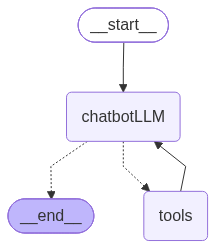

In [41]:
# Visualize the Graph
from IPython.display import Image, display

try:
    display(Image(compiled_graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

Now lets add question to test.

In [49]:
user_message = "I need some guidance in making youtube videos, I need experienced human assitance in this regard, i need expert adivce too."

config = {
    "configurable": {
        "thread_id": "hil_1"
    }
}

#Now streaming the events
events = compiled_graph.stream(
    {"messages": user_message},
    config,
    stream_mode="values"
)

Now Print the streamed values.


In [50]:
for event in events:    
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some guidance in making youtube videos, I need experienced human assitance in this regard, i need expert adivce too.
================================== Ai Message ==================================

[]
Tool Calls:
  human_assistance (A6ygI0QZ)
 Call ID: A6ygI0QZ
  Args:
    query: The user is requesting experienced human assistance and expert advice on making YouTube videos, covering video production, channel strategy, content planning, and growth.
================================== Ai Message ==================================

[]
Tool Calls:
  human_assistance (A6ygI0QZ)
 Call ID: A6ygI0QZ
  Args:
    query: The user is requesting experienced human assistance and expert advice on making YouTube videos, covering video production, channel strategy, content planning, and growth.


Since at this stage, human response will required to be sent, the streaming is paused. When user sends message, the streaming is resumed. So lets send reply as a Human message.

In [51]:
human_response = "Ok great! We are experts team in assisting you learn the core video skills and publish out of the box content."

# Pass human_command directly into stream to resume execution
human_command = Command(resume={"data": human_response})

events = compiled_graph.stream(
    human_command,
    config,
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================

[]
Tool Calls:
  human_assistance (A6ygI0QZ)
 Call ID: A6ygI0QZ
  Args:
    query: The user is requesting experienced human assistance and expert advice on making YouTube videos, covering video production, channel strategy, content planning, and growth.
================================= Tool Message =================================
Name: human_assistance

Ok great! We are experts team in assisting you learn the core video skills and publish out of the box content.
================================== Ai Message ==================================

[{'type': 'text', 'text': "Our expert team of YouTube specialists and video producers is ready to guide you step-by-step through mastering core video skills and publishing stand-out, high-performing content.\n\nTo tailor our expert advice specifically to your goals, please share:\n\n1. **Your Channel Goal & Niche:** What topic or style of videos are you planning t

In [53]:
user_message = "I need assistance in Travel video. I use DJI Osmo Action 4 camera. I have Wondershare software for editing."

config = {
    "configurable": {
        "thread_id": "hil_1"
    }
}

#Now streaming the events
events = compiled_graph.stream(
    {"messages": user_message},
    config,
    stream_mode="values"
)

for event in events:    
    if "messages" in event:
        event["messages"][-1].pretty_print()



================================ Human Message =================================

I need assistance in Travel video. I use DJI Osmo Action 4 camera. I have Wondershare software for editing.
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Great choice! The **DJI Osmo Action 4** combined with **Wondershare Filmora** is an ideal setup for travel content. The Action 4 excels at low-light performance, stabilization, and color depth, while Filmora offers fast, intuitive editing tools for cinematic travel videos.\n\nHere is an expert guide specifically tailored to your setup and niche:\n\n---\n\n### Phase 1: Camera Settings & Filming Strategy (DJI Osmo Action 4)\n\n#### 1. Best Camera Settings for Travel\n* **Resolution & Frame Rate:**\n  * **4K @ 24fps or 30fps:** Use this for standard talking scenes, scenery, and general walking/vlogging to give a natural, cinematic look.\n  * **4K @ 60fps or 120fps:** Switch to this for action, s